 # 01. Frequency & Severity Calibration

## Objective
Calibrate frequency and severity distributions
using real motor insurance data.

Determine which distributions best fit actual claim behavior —
and quantify how that choice affects capital requirements.

## Core Question
Which distribution fits the data?
And how does that choice affect SCR?

## Data
freMTPL2 — French Motor Third-Party Liability Insurance
Source: CASdatasets (Charpentier 2014), OpenML dataset 41214/41215
678,013 policies with varying exposure durations.

In [ ]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

pd.set_option('display.float_format', '{:.3f}'.format)

In [22]:
#load Data
freq = pd.read_csv('../data/freMTPL2freq.csv')
sev = pd.read_csv('../data/freMTPL2sev.csv')

print('freq shape:', freq.shape)
print('sev shape:', sev.shape)
print()
print('freq columns:', freq.columns.tolist())
print('sev columns:', sev.columns.tolist())

freq shape: (678013, 12)
sev shape: (26639, 2)

freq columns: ['IDpol', 'ClaimNb', 'Exposure', 'Area', 'VehPower', 'VehAge', 'DrivAge', 'BonusMalus', 'VehBrand', 'VehGas', 'Density', 'Region']
sev columns: ['IDpol', 'ClaimAmount']


## Part 1 — Data Overview

freMTPL2freq: one row per policy.
- ClaimNb: number of claims made against the policy
- Exposure: period of observation in years

freMTPL2sev: one row per claim.
- ClaimAmount: total financial loss of the claim (EUR)
- IDpol: links back to freMTPL2freq

In [ ]:
# Portfolio Overview 
total_exposure = freq['Exposure'].sum()
total_claims = freq['ClaimNb'].sum()
avg_claim_size = sev['ClaimAmount'].mean()

print('=== Portfolio Overview ===')
print(f'Total exposure: {total_exposure:.2f}')
print(f'Total claims: {total_claims}')
print(f'Claims per unit exposure: {total_claims / total_exposure:.6f}')
print(f'Average claim size: {avg_claim_size:.2f}')

=== Portfolio Overview ===
Total exposure: 358499.45
Total claims: 36102
Claims per unit exposure: 0.100703
Average claim size: 2278.54


In [ ]:
# Frequency Summary 
print('=== Frequency Summary ===')
print(freq[['ClaimNb', 'Exposure']].describe())

mean_claims = freq['ClaimNb'].mean()
var_claims = freq['ClaimNb'].var()

print()
print('Mean:            ', mean_claims)
print('Variance:        ', var_claims)
print('Variance / Mean: ', var_claims / mean_claims)

=== Frequency Summary ===
         ClaimNb   Exposure
count 678013.000 678013.000
mean       0.053      0.529
std        0.240      0.364
min        0.000      0.003
25%        0.000      0.180
50%        0.000      0.490
75%        0.000      0.990
max       16.000      2.010

Mean:             0.05324676665491664
Variance:         0.057656332380878514
Variance / Mean:  1.0828137744877455


In [ ]:
# Claim Count Distribution
claim_counts = freq['ClaimNb'].value_counts().sort_index()
claim_counts = claim_counts.reindex(range(0, 11), fill_value=0)
print(claim_counts)

ClaimNb
0     643953
1      32178
2       1784
3         82
4          7
5          2
6          1
7          0
8          1
9          1
10         0
Name: count, dtype: int64


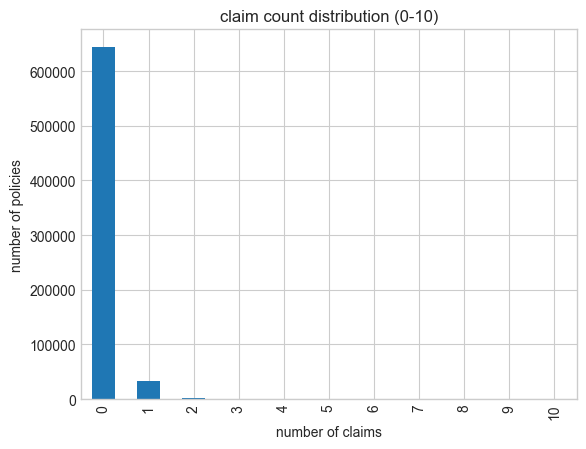

In [ ]:
# Claim Count Plot
claim_counts.plot(kind='bar')
plt.title('claim count distribution (0-10)')
plt.xlabel('number of claims')
plt.ylabel('number of policies')
plt.show()

In [ ]:
# Severity Summary
print('=== Severity Summary ===')
print(sev['ClaimAmount'].describe())

print()
print('Skewness:', round(sev['ClaimAmount'].skew(), 3))
print('Kurtosis:', round(sev['ClaimAmount'].kurt(), 3))

print()
print('Quantiles:')
print(sev['ClaimAmount'].quantile([0.9, 0.95, 0.99, 0.995, 0.999]))

=== Severity Summary ===
count     26639.000
mean       2278.536
std       29297.481
min           1.000
25%         686.810
50%        1172.000
75%        1228.080
max     4075400.560
Name: ClaimAmount, dtype: float64

Skewness: 109.564
Kurtosis: 14389.629

Quantiles:
0.900     2799.072
0.950     4861.685
0.990    16793.704
0.995    34386.987
0.999   162784.442
Name: ClaimAmount, dtype: float64


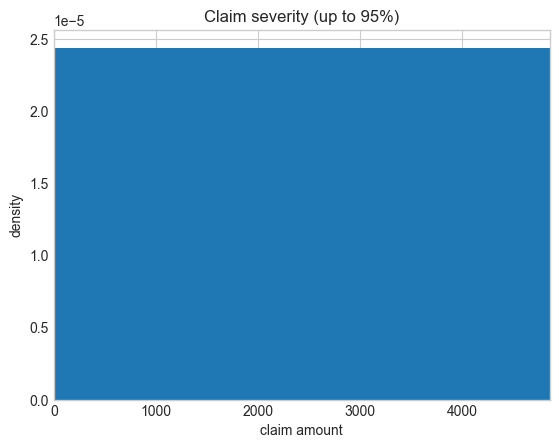

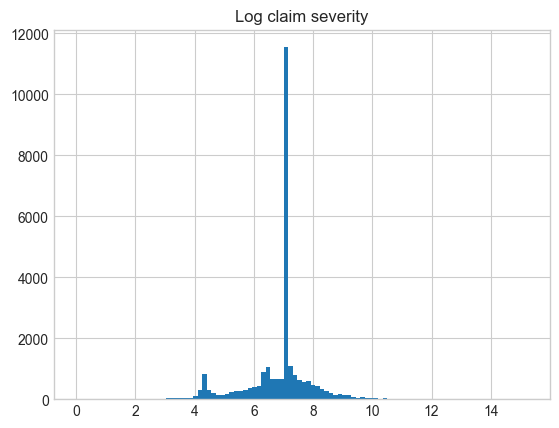

In [ ]:
# Severity Plot 
plt.hist(sev['ClaimAmount'], bins=100, density=True)
plt.xlim(0, sev['ClaimAmount'].quantile(0.95))
plt.title('Claim severity (up to 95%)')
plt.xlabel('claim amount')
plt.ylabel('density')
plt.show()

# log scale - heavy tail
plt.hist(np.log(sev['ClaimAmount']), bins=100)
plt.title('Log claim severity')
plt.show()

## Part 1 — Observations

About 95% of policies report zero claims, which is typical for motor insurance.

The variance-to-mean ratio is slightly above 1, suggesting mild overdispersion.
This will be examined more formally in part 2.

Claim sizes are strongly right-skewed.
Most losses are relatively small, but a few very large claims drive the upper tail.

The upper quantiles are significantly larger than the mean,
indicating the presence of a heavy tail.
This suggests that simple distributions may need to be complemented
with models that better capture tail behavior, which will be explored in part 3.

## Part 2 — Frequency Modeling

Goal: determine which distribution best describes
the number of claims per policy.

Candidates:
- Poisson: assumes mean = variance
- Negative Binomial: allows variance > mean (overdispersion)

From Part 1, the variance is slightly higher than the mean,
suggesting mild overdispersion.

Both models are therefore fitted and compared.

In [ ]:
# Poisson Fit 
from scipy.stats import poisson, nbinom
from scipy.optimize import minimize

# Poisson MLE — lambda = sample mean
lambda_mle = freq['ClaimNb'].mean()
print('=== Poisson MLE ===:')
print(f'  lambda = {lambda_mle:.6f}')

=== Poisson MLE ===:
  lambda = 0.053247


In [ ]:
# Negative Binomial Fit 
from scipy.special import gammaln

def nb_negloglik(params, data):
    r, p = params
    if r <= 0 or p <= 0 or p >= 1:
        return np.inf
    return -np.sum(nbinom.logpmf(data, r, p))

data = freq['ClaimNb'].values

result = minimize(
    nb_negloglik,
    x0=[1.0, 0.5],
    args=(data,),
    method='Nelder-Mead'
)

r_mle, p_mle = result.x

nb_mean = r_mle * (1 - p_mle) / p_mle
nb_var = r_mle * (1 - p_mle) / (p_mle ** 2)

print('=== Negative Binomial MLE ===')
print(f'r:                 {r_mle:.6f}')
print(f'p:                 {p_mle:.6f}')
print(f'Mean:              {nb_mean:.6f}')
print(f'Variance:          {nb_var:.6f}')
print(f'Variance / Mean:   {nb_var / nb_mean:.3f}')


=== Negative Binomial MLE ===
r:                 0.776909
p:                 0.935859
Mean:              0.053247
Variance:          0.056897
Variance / Mean:   1.069


In [ ]:
# Model Comparison: Log-Likelihood & AIC & BIC 

# Poisson log-likelihood
ll_poisson = np.sum(poisson.logpmf(data, lambda_mle))
aic_poisson = 2 * 1 - 2 * ll_poisson

# NB log-likelihood
ll_nb = np.sum(nbinom.logpmf(data, r_mle, p_mle))
aic_nb = 2 * 2 - 2 * ll_nb

# Log-Likelihood Comparison
print('=== Log-Likelihood Comparison ===')
print(f'Poisson log-likelihood:           {ll_poisson:.2f}')
print(f'Negative Binomial log-likelihood: {ll_nb:.2f}')
print()


# AIC Comparison 
print('=== AIC Comparison ===')
print(f'Poisson:             {aic_poisson:.2f}')
print(f'Negative Binomial:   {aic_nb:.2f}')
print(f'Difference:          {aic_poisson - aic_nb:.2f}')
print()

# BIC Comparison 
n = len(data)

bic_poisson = np.log(n) * 1 - 2 * ll_poisson
bic_nb = np.log(n) * 2 - 2 * ll_nb

print('=== BIC Comparison ===')
print(f'Poisson:             {bic_poisson:.2f}')
print(f'Negative Binomial:   {bic_nb:.2f}')
print(f'Difference:          {bic_poisson - bic_nb:.2f}')
print()

# Preferred Model
print('=== Preferred Model ===')
print('AIC: ', 'Negative Binomial' if aic_nb < aic_poisson else 'Poisson')
print('BIC: ', 'Negative Binomial' if bic_nb < bic_poisson else 'Poisson')

=== Log-Likelihood Comparison ===
Poisson log-likelihood:           -143511.09
Negative Binomial log-likelihood: -142909.46

=== AIC Comparison ===
Poisson:             287024.17
Negative Binomial:   285822.91
Difference:          1201.26

=== BIC Comparison ===
Poisson:             287035.60
Negative Binomial:   285845.77
Difference:          1189.83

=== Preferred Model ===
AIC:  Negative Binomial
BIC:  Negative Binomial


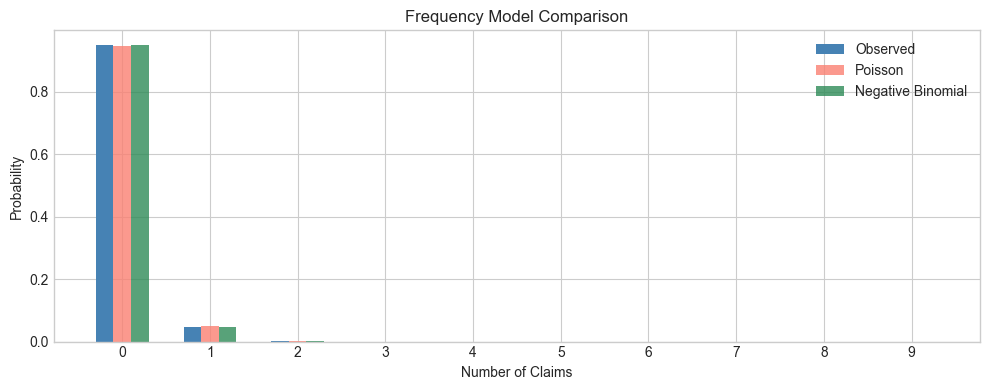

In [ ]:
# Visual Comparison 
k_vals = np.arange(0, 10)

# Poisson probabilities
pmf_poisson = poisson.pmf(k_vals, lambda_mle)

# NB probabilities
pmf_nb = nbinom.pmf(k_vals, r_mle, p_mle)

# observed proportions
observed = freq['ClaimNb'].value_counts(normalize=True).sort_index()
observed = observed.reindex(k_vals, fill_value=0)

plt.figure(figsize=(10, 4))

plt.bar(k_vals - 0.2, observed, width=0.2, 
        label='Observed', color='steelblue')

plt.bar(k_vals, pmf_poisson, width=0.2, 
        label='Poisson', color='salmon', alpha=0.8)

plt.bar(k_vals + 0.2, pmf_nb, width=0.2, 
        label='Negative Binomial', color='seagreen', alpha=0.8)

plt.xticks(k_vals)

plt.title('Frequency Model Comparison')
plt.xlabel('Number of Claims')
plt.ylabel('Probability')

plt.legend()
plt.tight_layout()
plt.show()

## Part 2 — Results

Poisson MLE:
- λ = 0.053  

Negative Binomial MLE:
- r = 0.777  
- p = 0.936  

The Negative Binomial model has a slightly higher variance than the mean
(variance-to-mean ratio ≈ 1.07), indicating mild overdispersion in the data.

Log-likelihood comparison:
- Poisson: −143,511  
- Negative Binomial: −142,909  

Model selection criteria:
- AIC: Poisson = 287,024, Negative Binomial = 285,823  
- BIC: Poisson = 287,036, Negative Binomial = 285,846  

Both AIC and BIC favor the Negative Binomial model, with differences of over 1,000,
indicating a consistently better fit.

The improvement reflects the ability of the Negative Binomial model
to capture slight deviations from the Poisson assumption.

Therefore, the Negative Binomial distribution is selected as the frequency model,
and its parameters (r, p) will be used in the aggregate loss simulation.

## Part 3 — Severity Modeling

Goal: determine which distribution best fits individual claim sizes.

Candidates:
- Lognormal: standard choice for motor claims
- Gamma: flexible alternative
- Pareto: heavy tail, used as stress scenario

From Part 1: skewness = 109, kurtosis = 14389.
Extreme right skew suggests heavy tail behavior.

In [ ]:
# Data Preparation 
losses = sev['ClaimAmount'].values
losses = losses[losses > 0]

print(f'Total claims: {len(losses)}')
print(f'Min: {losses.min():.2f}')
print(f'Max: {losses.max():.2f}')
print(f'Mean: {losses.mean():.2f}')

Total claims: 26639
Min: 1.00
Max: 4075400.56
Mean: 2278.54


In [ ]:
# Lognormal Fit 
sigma_ln, loc_ln, scale_ln = stats.lognorm.fit(losses, floc=0)
mu_ln = np.log(scale_ln)

ll_ln = np.sum(stats.lognorm.logpdf(losses, sigma_ln, loc=0, scale=scale_ln))
aic_ln = 2 * 2 - 2 * ll_ln
bic_ln = np.log(len(losses)) * 2 - 2 * ll_ln

print('Lognormal MLE:')
print(f'  mu    = {mu_ln:.4f}')
print(f'  sigma = {sigma_ln:.4f}')
print(f'  AIC   = {aic_ln:.2f}')
print(f'  BIC   = {bic_ln:.2f}')

Lognormal MLE:
  mu    = 6.8498
  sigma = 1.1327
  AIC   = 447184.27
  BIC   = 447200.65


In [ ]:
# Gamma Fit 
a_gam, loc_gam, scale_gam = stats.gamma.fit(losses, floc=0)

ll_gam = np.sum(stats.gamma.logpdf(losses, a_gam, loc=0, scale=scale_gam))
aic_gam = 2 * 2 - 2 * ll_gam
bic_gam = np.log(len(losses)) * 2 - 2 * ll_gam

print('Gamma MLE:')
print(f'  shape = {a_gam:.4f}')
print(f'  scale = {scale_gam:.4f}')
print(f'  AIC   = {aic_gam:.2f}')
print(f'  BIC   = {bic_gam:.2f}')

Gamma MLE:
  shape = 0.6874
  scale = 3314.8420
  AIC   = 462312.01
  BIC   = 462328.39


In [ ]:
# Pareto Fit 
b_par, loc_par, scale_par = stats.pareto.fit(losses, floc=0)

ll_par = np.sum(stats.pareto.logpdf(losses, b_par, loc=0, scale=scale_par))
aic_par = 2 * 2 - 2 * ll_par
bic_par = np.log(len(losses)) * 2 - 2 * ll_par

print('Pareto MLE:')
print(f'  shape = {b_par:.4f}')
print(f'  scale = {scale_par:.4f}')
print(f'  AIC   = {aic_par:.2f}')
print(f'  BIC   = {bic_par:.2f}')

Pareto MLE:
  shape = 0.1460
  scale = 1.0000
  AIC   = 520746.49
  BIC   = 520762.87


In [ ]:
# AIC / BIC Comparison
print('=== Model Comparison ===')
print(f"{'Model':<12} {'AIC':>12} {'BIC':>12}")
print('-' * 38)
print(f"{'Lognormal':<12} {aic_ln:>12.2f} {bic_ln:>12.2f}")
print(f"{'Gamma':<12} {aic_gam:>12.2f} {bic_gam:>12.2f}")
print(f"{'Pareto':<12} {aic_par:>12.2f} {bic_par:>12.2f}")
print()

best_aic = min([('Lognormal', aic_ln), ('Gamma', aic_gam), ('Pareto', aic_par)], key=lambda x: x[1])
best_bic = min([('Lognormal', bic_ln), ('Gamma', bic_gam), ('Pareto', bic_par)], key=lambda x: x[1])

print(f'Best fit by AIC: {best_aic[0]}')
print(f'Best fit by BIC: {best_bic[0]}')

=== Model Comparison ===
Model                 AIC          BIC
--------------------------------------
Lognormal       447184.27    447200.65
Gamma           462312.01    462328.39
Pareto          520746.49    520762.87

Best fit by AIC: Lognormal
Best fit by BIC: Lognormal


In [ ]:
# Tail Comparison 
quantiles = [0.9, 0.95, 0.99, 0.995, 0.999]

print('=== Tail Comparison ===')
print(f"{'Quantile':<12} {'Observed':>12} {'Lognormal':>12} {'Gamma':>12} {'Pareto':>12}")
print('-' * 52)

for q in quantiles:
    obs = np.quantile(losses, q)
    ln_q = stats.lognorm.ppf(q, sigma_ln, loc=0, scale=scale_ln)
    gam_q = stats.gamma.ppf(q, a_gam, loc=0, scale=scale_gam)
    par_q = stats.pareto.ppf(q, b_par, loc=0, scale=scale_par)
    print(f"{q:<12} {obs:>12.0f} {ln_q:>12.0f} {gam_q:>12.0f} {par_q:>12.0f}")

=== Tail Comparison ===
Quantile         Observed    Lognormal        Gamma       Pareto
----------------------------------------------------
0.9                  2799         4029         5744      7076807
0.95                 4862         6081         7807    816288887
0.99                16794        13158        12738 50081201563648
0.995               34387        17455        14900 5776719151823359
0.999              162784        31257        19973 354415012826583793664


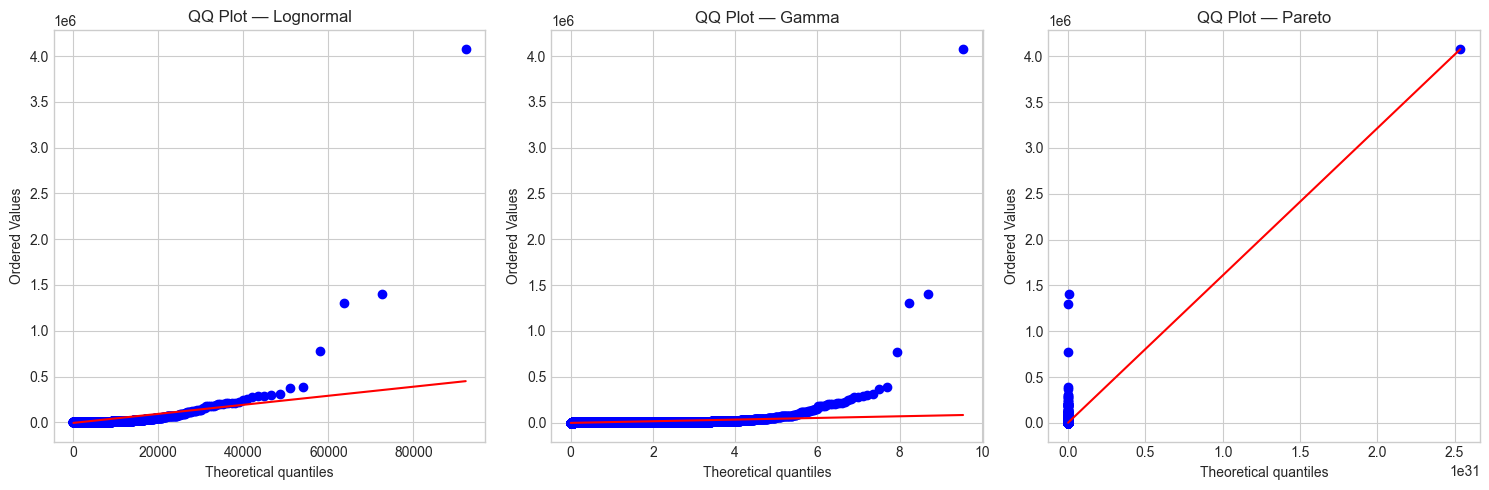

In [ ]:
# QQ Plot 
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (name, dist, params) in zip(axes, [
    ('Lognormal', stats.lognorm, (sigma_ln, 0, scale_ln)),
    ('Gamma',     stats.gamma,   (a_gam, 0, scale_gam)),
    ('Pareto',    stats.pareto,  (b_par, 0, scale_par))
]):
    stats.probplot(losses, dist=dist, sparams=params[:-1] if name != 'Lognormal' else params, plot=ax)
    ax.set_title(f'QQ Plot — {name}')

plt.tight_layout()
plt.show()

## Part 3 — Results

AIC and BIC both select Lognormal as the best overall fit.

However, tail comparison reveals a material limitation:
at high quantiles, Lognormal underestimates extreme losses.

This suggests that a single-distribution severity model is not sufficient
to capture both the body and the tail of the loss distribution.

Lognormal is therefore retained as the base severity model,
while a spliced tail specification will be introduced next
to better represent extreme claims.

## Part 3.1 — Spliced Distribution

Single distributions fail at the tail — AIC and BIC favors Lognormal
but it underestimates losses at the 99.5% SCR threshold by 50%.

A spliced model combines two distributions:
- Below threshold: Lognormal (body — typical claims)
- Above threshold: GPD (tail — extreme claims)

This is the Peaks Over Threshold (POT) method from Extreme Value Theory,
the standard approach for tail modeling in insurance and risk management.

In [ ]:
# Threshold Selection 
threshold = np.percentile(losses, 99)
print(f'Threshold (90th percentile): {threshold:.2f}')

below = losses[losses <= threshold]
above = losses[losses > threshold]

alpha = len(below) / len(losses)

print(f'Claims below threshold: {len(below)} ({alpha*100:.1f}%)')
print(f'Claims above threshold: {len(above)} ({(1-alpha)*100:.1f}%)')

Threshold (90th percentile): 16793.70
Claims below threshold: 26372 (99.0%)
Claims above threshold: 267 (1.0%)


In [ ]:
# Fit Below Threshold: Lognormal (body)
sigma_sp, loc_sp, scale_sp = stats.lognorm.fit(below, floc=0)
mu_sp = np.log(scale_sp)

print('Lognormal fit (below threshold):')
print(f'  mu    = {mu_sp:.4f}')
print(f'  sigma = {sigma_sp:.4f}')

Lognormal fit (below threshold):
  mu    = 6.8111
  sigma = 1.0669


In [106]:
# Fit Above Threshold: Pareto (tail)
excess = above - threshold
b_sp, loc_sp_par, scale_sp_par = stats.pareto.fit(excess, floc=0)

print('Pareto fit (above threshold):')
print(f'  shape = {b_sp:.4f}')
print(f'  scale = {scale_sp_par:.4f}')

Pareto fit (above threshold):
  shape = 0.1238
  scale = 4.7956


## Part 3.1 — Results

Pareto shape = 0.12 — extremely heavy tail.
This caused unstable sampling with tail values exceeding 3 billion EUR.

Single distributions cannot reliably capture both body and tail.
A more robust approach is needed for extreme loss modeling.

→ Moving to Extreme Value Theory: Spliced Lognormal + GPD

## Part 3.2 — GPD Tail Modeling

Standard Pareto fit produced unstable shape (0.12),
causing extreme overestimation in the tail.

GPD is theoretically correct for excess losses above a threshold.
For excess Y = X - threshold where X > threshold:
Y ~ GPD(xi, sigma)

xi > 0 confirms heavy tail.

In [ ]:
# GPD Fit on Excess Losses 
from scipy.stats import genpareto

excess = above - threshold

xi_gpd, loc_gpd, sigma_gpd = genpareto.fit(excess, floc=0)

print('GPD fit (excess over threshold):')
print(f'  xi (shape) = {xi_gpd:.4f}')
print(f'  sigma      = {sigma_gpd:.4f}')
print()
if xi_gpd > 0:
    print('Heavy tail confirmed (xi > 0)')
elif xi_gpd == 0:
    print('Exponential tail')
else:
    print('Bounded tail')

GPD fit (excess over threshold):
  xi (shape) = 0.8519
  sigma      = 17465.0603

Heavy tail confirmed (xi > 0)


In [ ]:
# Spliced: Lognormal + GPD 
def sample_spliced_gpd(n):
    samples = []
    for _ in range(n):
        if np.random.random() < alpha:
            s = stats.lognorm.rvs(sigma_sp, loc=0, scale=scale_sp)
            s = min(s, threshold)
        else:
            excess_sample = genpareto.rvs(xi_gpd, loc=0, scale=sigma_gpd)
            s = threshold + excess_sample
        samples.append(s)
    return np.array(samples)

spliced_samples = sample_spliced_gpd(10000)
print(f'Mean:   {spliced_samples.mean():.2f}')
print(f'Std:    {spliced_samples.std():.2f}')
print(f'99.5%:  {np.percentile(spliced_samples, 99.5):.2f}')
print(f'99.9%:  {np.percentile(spliced_samples, 99.9):.2f}')

Mean:   2272.26
Std:    15702.90
99.5%:  31627.18
99.9%:  121385.58


In [ ]:
# Tail Comparison Final 
print('=== Tail Comparison — Final ===')
print(f"{'Quantile':<12} {'Observed':>12} {'Lognormal':>12} {'Spliced GPD':>12}")
print('-' * 52)

for q in quantiles:
    obs = np.quantile(losses, q)
    ln_q = stats.lognorm.ppf(q, sigma_ln, loc=0, scale=scale_ln)
    sp_q = np.quantile(spliced_samples, q)
    print(f"{q:<12} {obs:>12.0f} {ln_q:>12.0f} {sp_q:>12.0f}")

=== Tail Comparison — Final ===
Quantile         Observed    Lognormal  Spliced GPD
----------------------------------------------------
0.9                  2799         4029         3668
0.95                 4862         6081         5801
0.99                16794        13158        16952
0.995               34387        17455        32291
0.999              162784        31257       135591


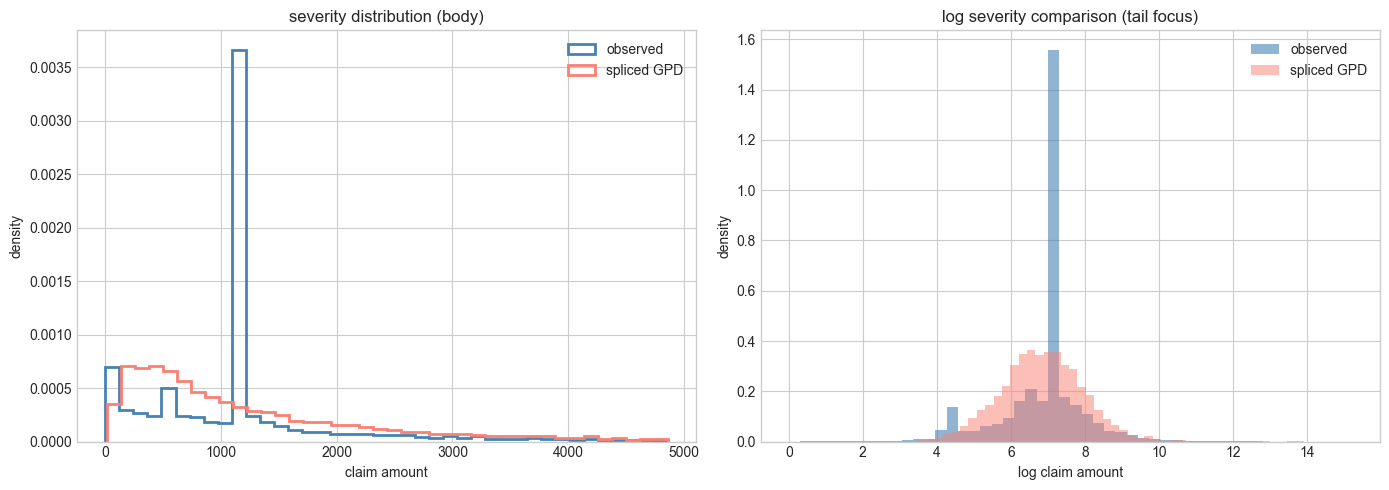

In [108]:
# Visualisation: Tail Comparison (Final) 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# left — body comparison with step histograms

body_limit = np.percentile(losses, 95)

axes[0].hist(losses[losses <= body_limit], bins=40, density=True,
             histtype='step', linewidth=2, color='steelblue', label='observed')
axes[0].hist(spliced_samples[spliced_samples <= body_limit], bins=40, density=True,
             histtype='step', linewidth=2, color='salmon', label='spliced GPD')
axes[0].set_title('severity distribution (body)')
axes[0].set_xlabel('claim amount')
axes[0].set_ylabel('density')
axes[0].legend()

log_losses = np.log(losses[losses > 0])
log_spliced = np.log(spliced_samples[spliced_samples > 0])

axes[1].hist(log_losses, bins=50, density=True, alpha=0.6,
             color='steelblue', label='observed')
axes[1].hist(log_spliced, bins=50, density=True, alpha=0.5,
             color='salmon', label='spliced GPD')
axes[1].set_title('log severity comparison (tail focus)')
axes[1].set_xlabel('log claim amount')
axes[1].set_ylabel('density')
axes[1].legend()

plt.tight_layout()
plt.show()

## Part 3.2 — Results

Spliced Lognormal + GPD model:
- Threshold:  16,794 EUR (99th percentile)
- Lognormal:  mu = 6.81, sigma = 1.07
- GPD:        xi = 0.85, sigma = 17,465

GPD xi = 0.85 confirms heavy tail — consistent with Part 1 observations.

Tail comparison at SCR threshold (99.5%):
- Observed:      34,387
- Lognormal:     17,455  (underestimates by 49%)
- Spliced GPD:   32,291  (within 6% of observed)

Spliced Lognormal + GPD significantly improves tail risk estimation,
reducing underestimation from ~49% (Lognormal) to ~6%.

This is critical for SCR (99.5% VaR) calculation,
where accurate tail modeling directly impacts capital requirements.

Model limitation: discrete spikes in observed data reflect
insurance-specific features (rounding, fixed claim amounts).
The continuous model is an approximation — acceptable for capital modeling.

This demonstrates that tail model specification has a first-order impact
on regulatory capital requirements under Solvency II.